In [31]:
import pandas as pd

df = pd.read_csv(r"C:\Users\owner\Downloads\Micron_MU_NetIncome_Price_PE_2004_2025.csv")
df.head()

,Year,Net_Income_USD_mm,Diluted_EPS_USD,Stock_Price_USD,PE_Ratio,Data_Type,Source_Notes
0,# SOURCES: Net Income & EPS from SEC EDGAR 10-...,Annual stock price = FY-end close (~last Thu A...,2025 = TTM through Q3 FY2025 (May 29 2025); pr...,P/E = Price / Diluted EPS; N/M = Not Meaningfu...,NaN,NaN,NaN
1,2004,147,0.3,12.5,41.7,Annual FY,10-K FY2004; DRAM demand recovery
2,2005,188,0.29,10.8,37.2,Annual FY,10-K FY2005; DRAM pricing pressure
3,2006,408,0.62,13.2,21.3,Annual FY,10-K FY2006; improved margins
4,2007,-320,-0.49,8.9,N/M,Annual FY,10-K FY2007; DRAM oversupply; net loss


## Wrangle data

In [32]:
df.drop(0, inplace=True) # remove first row
df = df.reset_index(drop=True)

In [34]:
df[['Year', 'Net_Income_USD_mm']] = df[['Year', 'Net_Income_USD_mm']].astype('int')
df[[ 'Diluted_EPS_USD', 'Stock_Price_USD']] = df[[ 'Diluted_EPS_USD', 'Stock_Price_USD']].astype('float')
df['PE_Ratio'] = round(df['Stock_Price_USD']/df['Diluted_EPS_USD'], 2) # calculate PE
df.iloc[12, 4] = -20 # change outlier

## Visualise data

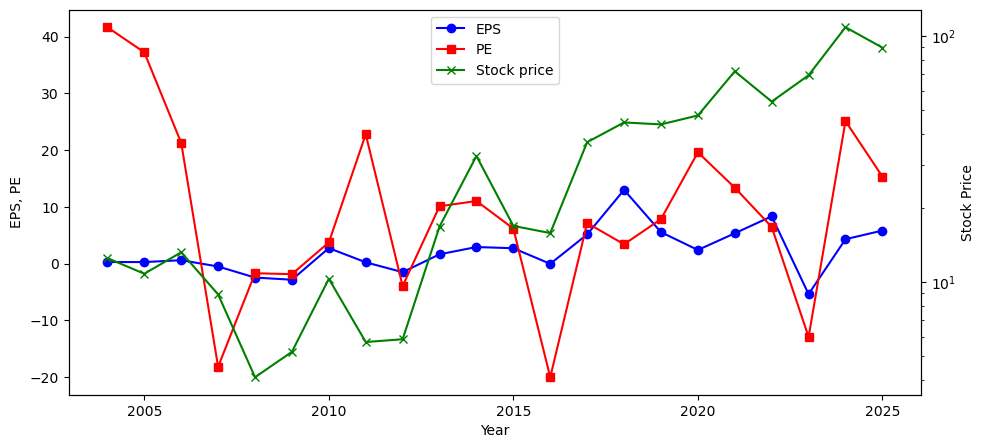

In [58]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11, 5))
l1 = ax1.plot(df['Year'], df['Diluted_EPS_USD'], color='b', marker='o', label='EPS')
l2 = ax1.plot(df['Year'], df['PE_Ratio'], color='r', marker='s', label='PE')
ax1.set_xlabel('Year')
ax1.set_ylabel('EPS, PE')
ax2 = ax1.twinx()
ax2.set_ylabel('Stock Price')
ax2.set_yscale('log', base=10)
l3 = ax2.plot(df['Year'], df['Stock_Price_USD'], color='g', marker='x', label='Stock price')
lines = l1+l2+l3
labs = [l.get_label() for l in lines]
plt.legend(lines, labs, loc='upper center')
plt.show()

## It is evident that micron (which is part of the memory chips industry) is highly cyclical 
### - The average time between peaks seem to be roughly 4 years
### - The company may reach the peak of its cycle soon